In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from trading_simulator import TradingSimulator

# Load data

In [9]:
prices = pd.read_csv('prices_real_dates.csv', index_col='Date', parse_dates=['Date'])
ret = prices.diff()

# Currency denomination for each equity
equity_ccy = {
    'Stock_01': 'Crncy_03', 'Stock_02': 'Crncy_04', 'Stock_03': 'Crncy_04',
    'Stock_04': 'Crncy_02', 'Stock_05': 'Crncy_03', 'Stock_06': 'Crncy_02',
    'Stock_07': 'Crncy_03', 'Stock_08': 'Crncy_02', 'Stock_09': 'Crncy_04',
    'Stock_10': 'Crncy_03', 'Stock_11': 'Crncy_01', 'Stock_12': 'Crncy_04',
    'Stock_13': 'Crncy_01', 'Stock_14': 'Crncy_01', 'Stock_15': 'Crncy_01',
}

# FX pairs: ticker → (base_currency, quote_currency)
fx_pairs_map = {
    'FX_01': ('Crncy_02', 'Crncy_01'),
    'FX_02': ('Crncy_04', 'Crncy_02'),
    'FX_03': ('Crncy_04', 'Crncy_03'),
    'FX_04': ('Crncy_02', 'Crncy_03'),
    'FX_05': ('Crncy_01', 'Crncy_03'),
    'FX_06': ('Crncy_04', 'Crncy_01'),
}

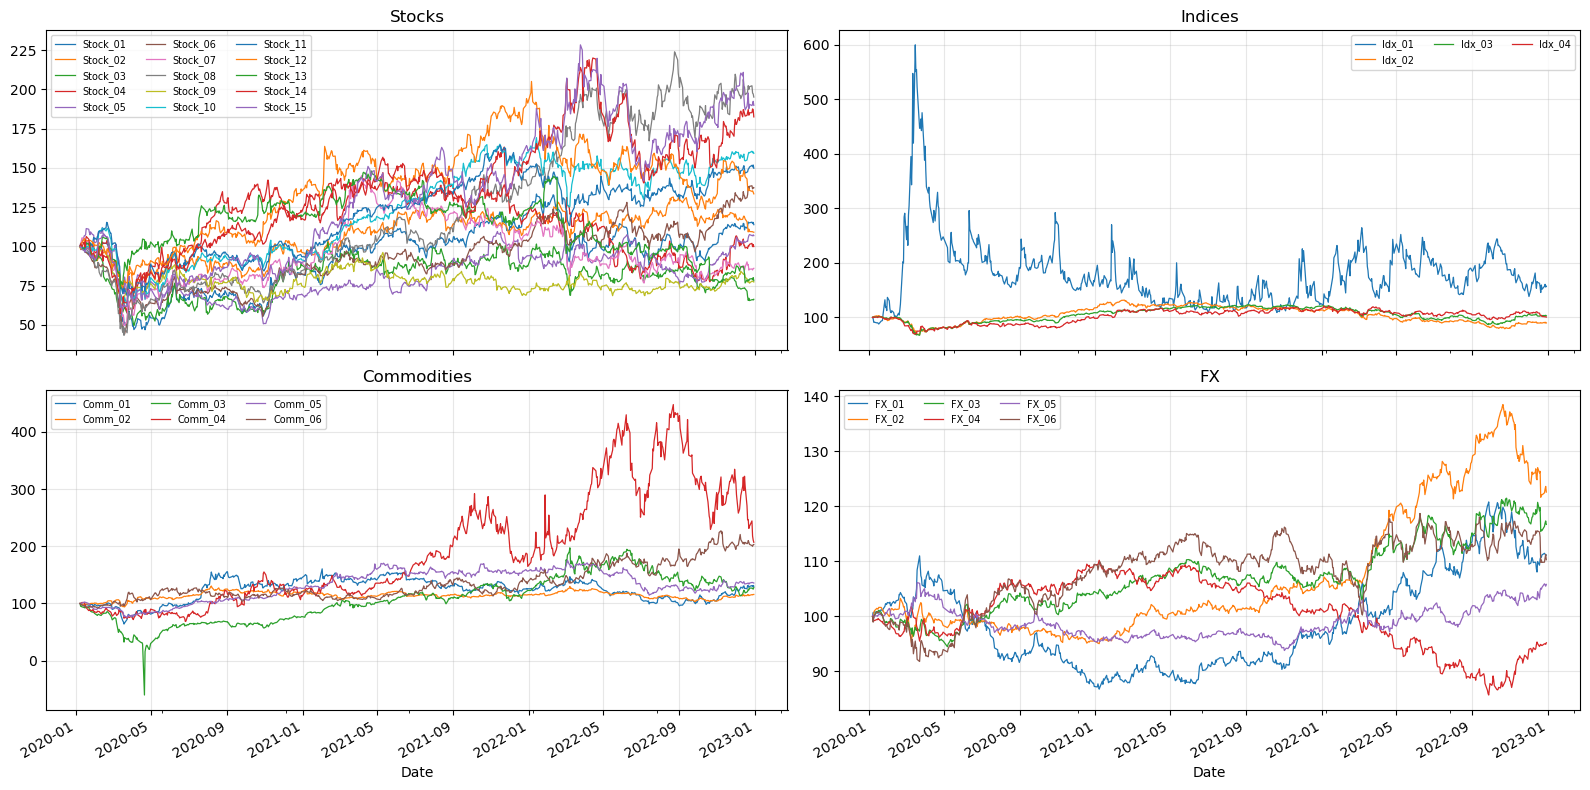

In [10]:
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
for ax, (title, prefix) in zip(axes.flat, [("Stocks","Stock_"),("Indices","Idx_"),("Commodities","Comm_"),("FX","FX_")]):
    cols = [c for c in prices.columns if c.startswith(prefix)]
    (prices[cols] / prices[cols].iloc[0] * 100).plot(ax=ax, linewidth=0.9, legend=True)
    ax.set_title(title); ax.legend(fontsize=7, ncol=3); ax.grid(alpha=0.3)
plt.tight_layout()

## Strategy example

In [4]:
# ── 1. Asset columns ──────────────────────────────────────────────────────────
STOCK_COLS = [c for c in prices.columns if c.startswith('Stock_')]
FX_COLS    = [c for c in prices.columns if c.startswith('FX_')]

# ── 2. Model parameters ───────────────────────────────────────────────────────
TREND_WINDOW   = 50    # days to look back for trend direction (buy if up, sell if down)
VOL_WINDOW     = 100   # days to estimate volatility per stock
RISK_WINDOW    = 100   # days to estimate total portfolio risk (shrinks all positions if risky)

def compute_positions(stock_prices):
    """
    Trend-following with vol scaling and portfolio risk adjustment.
    Signal: +1 if cumulative return over TREND_WINDOW is positive, -1 if negative.
    Position size = signal / vol / portfolio_risk — controls both per-stock and total risk.
    """
    daily_returns = stock_prices.pct_change()

    # Trend signal: up over last TREND_WINDOW days → long, down → short
    signal     = np.sign(daily_returns.rolling(TREND_WINDOW).sum())

    # Vol scaling: smaller positions in volatile stocks
    volatility = np.sqrt(
        (daily_returns ** 2).rolling(VOL_WINDOW, min_periods=VOL_WINDOW // 2).sum()
    )
    vol_scaled_pos = signal / volatility.replace(0, np.nan)

    # Portfolio risk: shrink all positions when the whole model is swinging a lot
    portfolio_daily_pnl = (vol_scaled_pos.shift(2) * daily_returns).dropna(how='all').sum(axis=1)
    portfolio_risk      = portfolio_daily_pnl.rolling(RISK_WINDOW, min_periods=20).std()

    return vol_scaled_pos.div(portfolio_risk, axis=0) 

# Precompute target positions for all dates at once (fast — no day-by-day loop)
target_shares_df = compute_positions(prices[STOCK_COLS])

# ── 3. Strategy function (called once per day by the simulator) ───────────────
def hedged_trend_strategy(row_pos, cash, portfolio, signal_prices, data):
    orders = []
    date   = data.index[row_pos]

    if date not in target_shares_df.index:
        return orders

    targets = target_shares_df.loc[date]
    if targets.isna().all():
        return orders

    # --- Equity orders: trade the delta between current and target holdings ---
    total_equity_notional = 0.0
    for ticker in STOCK_COLS:
        tgt = targets.get(ticker)
        if pd.isna(tgt):
            continue
        tgt   = int(round(tgt))
        delta = tgt - portfolio.get(ticker, 0)
        if delta != 0:
            orders.append(('BUY' if delta > 0 else 'SELL', ticker, abs(delta)))
        total_equity_notional += abs(tgt * signal_prices[ticker])

    # --- Naive FX hedge: spread total equity notional equally across all FX pairs ---
    hedge_per_pair = total_equity_notional / len(FX_COLS)
    for fx_ticker in FX_COLS:
        fx_price = signal_prices.get(fx_ticker, 100.0)
        tgt_fx   = -int(round(hedge_per_pair / fx_price))
        delta_fx = tgt_fx - portfolio.get(fx_ticker, 0)
        if delta_fx != 0:
            orders.append(('BUY' if delta_fx > 0 else 'SELL', fx_ticker, abs(delta_fx)))

    return orders


## Evaluate strategy

Saved performance plot to 'performance_plot.png'


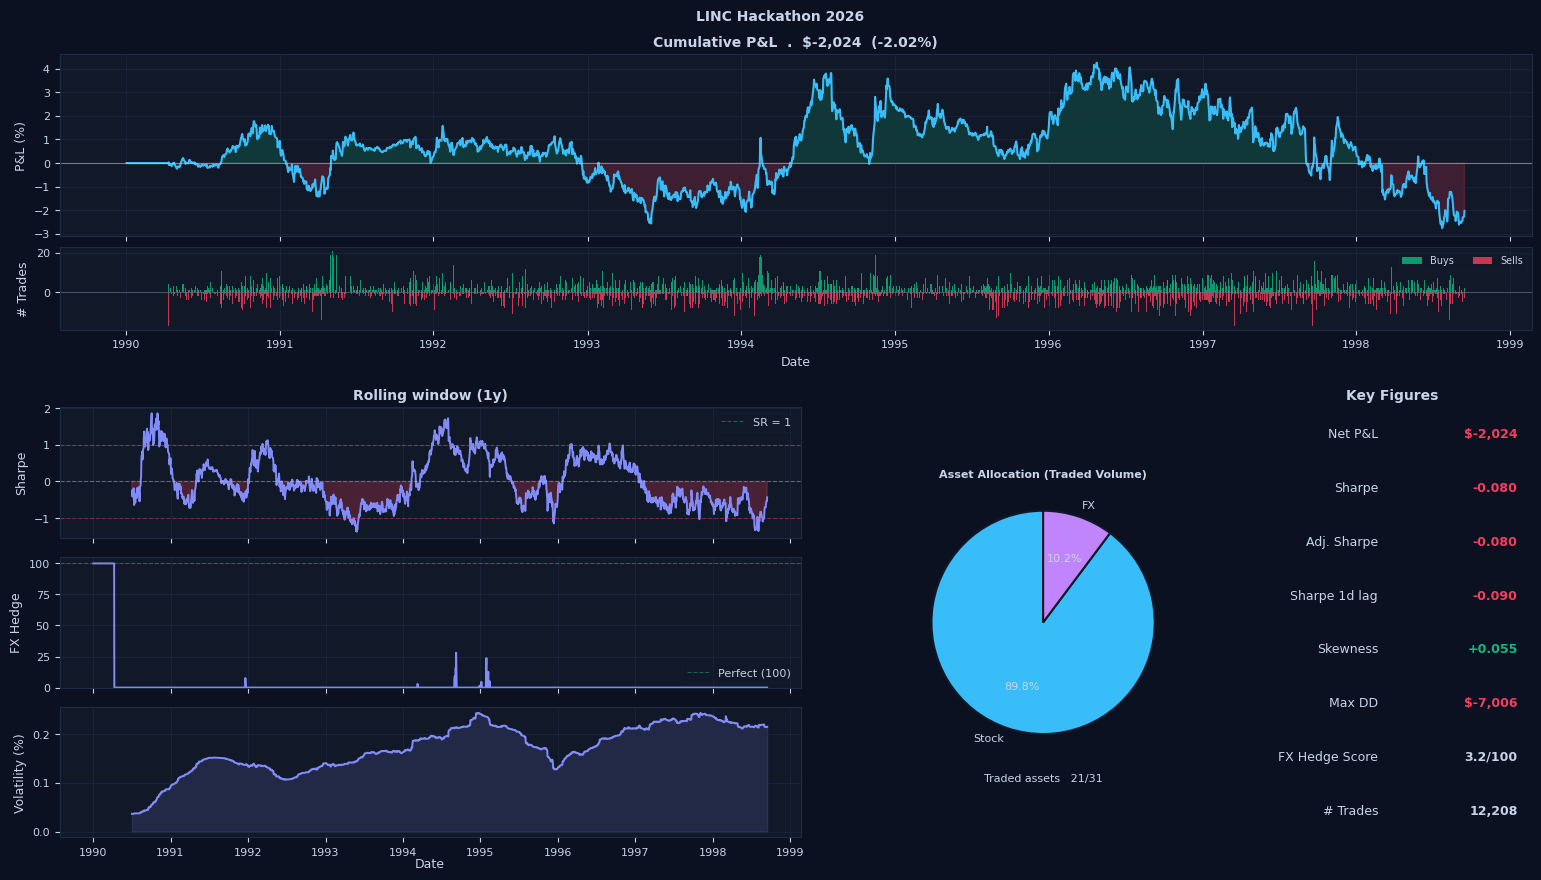


  TRADING SUMMARY
  Initial Cash      $    100,000.00
  Final Value       $     97,975.65
  Net P&L           $     -2,024.35  (-2.02%)
  Sharpe                    -0.080
  Adjusted Sharpe           -0.080
  Sharpe 1d lag             -0.090
  Skewness                   0.055
  FX Hedge Score              0.0/100
  Max Drawdown      $     -7,005.56
  # Trades                  12,208

Saved 12208 orders to 'orders.csv'
Saved 2271 portfolio snapshots to 'portfolio.csv'


In [5]:
sim = TradingSimulator(
    assets              = list(prices.columns),
    initial_cash        = 100_000,
    equity_currency_map = equity_ccy,
    fx_pairs_map        = fx_pairs_map,
)
sim.run(hedged_trend_strategy, prices, prices)
sim.plot_performance(prices)

# Save results to csv files
sim.save_results(orders_file="orders.csv", portfolio_file="portfolio.csv")

## Check for forward-looking bias

Once you're happy with your strategy, copy it into `algorithm.py` and run the causal check.

The checker runs `algorithm.py` **twice** — once normally, then again with a small price change applied to a date in the **second half** of the data. If any orders **before the halfway point** change between the two runs, your strategy is accidentally using future data.

```
PASS → orders before cutoff are identical → no lookahead bias detected
FAIL → orders changed → your strategy is peeking at future prices
```

Run it from the terminal:
```bash
python check_causal.py
```

Or directly from this notebook:


In [ ]:
import subprocess, sys
result = subprocess.run([sys.executable, 'check_causal.py'], capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)